# use_nbhood 官方数据对比

本 notebook 读取 `neighbourhood_probability_processing/test_data/official_test_use_nohood` 中的官方输入、辅助数据、官方 KGO 和原算法输出，调用迁移后的 `ApplyNeighbourhoodProcessingWithAMask` 进行处理，并绘制辅助数据图与结果对比图。

**受原算法输入约束**：原方法插件内部不做投影转经纬或重网格，只接受投影坐标输入。因此本 notebook 仅做**维名重命名**（投影维 → `lat`/`lon`，数值仍为米制投影坐标），不设「经纬重网格」第二套验证方案；KGO 与 `original_*.nc` 直接读取数据根目录下的官方投影 nc。

## 1. 环境与参数

这里完成依赖导入、路径定位和本次 use_nbhood 对比使用的统一参数设置。

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "SimSun", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

# 支持从 notebook 所在目录运行，也支持从工程根目录启动 Jupyter 后运行。
NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR.parent / "test_data" / "official_test_use_nbhood").exists():
    NOTEBOOK_DIR = Path(r"D:\workspace\improver\nbhood\nbs")

PROJECT_DIR = NOTEBOOK_DIR.parent
ROOT_DIR = NOTEBOOK_DIR.parents[1] #项目根目录
RESOURCE_DIR = PROJECT_DIR / "test_data" / "official_test_use_nbhood"
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from neighbourhood_probability_processing.src.use_nbhood import ApplyNeighbourhoodProcessingWithAMask

COORD_FOR_MASKING = "topographic_zone"
RADIUS_METRES = 10000.0
THRESHOLD_INDEX = 0
BAND_INDEX = 1
FILL_THRESHOLD = 1.0e20


d:\workspace\improver\venv\Lib\site-packages\meteva_base\basicdata\const.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 1.1 数据预处理

把原始投影样例整理成各场景 `cli_input/` 下的六维输入，分三类：

- **数据场**（`input` / `thresholded_input`）→ meteva_base 标准六维 `(member,level,time,dtime,lat,lon)`；
- **掩码**（`topography_mask` / `land_binary_mask`，可能含 `topographic_zone` 分层）→ 重命名 `lat/lon` + 清缺测，保留分层维；
- **权重**（`topographic_zone_weights`）→ 同掩码。

统一把 `projection_x/y_coordinate` 重命名为 `lon/lat`（仅改名不改数值）。KGO / 原算法参考仍保留在场景子目录；CLI 写出结果到 `cli_output/`。

In [2]:
"""use_nbhood 输入预处理：把投影规则网格整理成 meteva_base 六维 / 分带格式。

三类数据：
- **数据场**（input / thresholded_input）→ 标准六维 ``(member,level,time,dtime,lat,lon)``；
- **掩码**（topography_mask / land_binary_mask，可能含 ``topographic_zone`` 分层）→ 重命名 lat/lon + 清缺测，保留分层维；
- **权重**（topographic_zone_weights）→ 同掩码。

统一把 ``projection_x/y_coordinate`` 重命名为 ``lon/lat``（仅改名不改数值），大填充值 / 非有限值统一置 ``NaN``。
"""

MEMBER_LIKE_DIMS = ("member", "realization", "threshold", "number", "ensemble_member", "percentile")


def load_primary(path, var_name=None, *, mask_and_scale=False):
    """读取 NetCDF 主变量（跳过 ``*_bnds`` 与网格映射标量）。"""
    ds = xr.open_dataset(path, decode_timedelta=False, mask_and_scale=mask_and_scale)
    try:
        if var_name and var_name in ds.data_vars:
            return ds[var_name].load()
        for name, da in ds.data_vars.items():
            if name.endswith("_bnds"):
                continue
            if da.ndim == 0 and "grid_mapping_name" in da.attrs:
                continue
            return da.load()
        raise ValueError(f"{path} 中未找到主变量")
    finally:
        ds.close()


def _rename_projection_to_latlon(da):
    """投影坐标维 projection_x/y_coordinate 重命名为 lon/lat（不改数值），并按升序排列。"""
    rename_map = {}
    if "projection_y_coordinate" in da.dims:
        rename_map["projection_y_coordinate"] = "lat"
    if "projection_x_coordinate" in da.dims:
        rename_map["projection_x_coordinate"] = "lon"
    if rename_map:
        da = da.rename(rename_map)
    attrs = dict(da.attrs)
    attrs.pop("grid_mapping", None)
    da.attrs = attrs
    if "lat" in da.dims:
        da = da.sortby("lat")
    if "lon" in da.dims:
        da = da.sortby("lon")
    return da


def _clean_fill_values(values, threshold=FILL_THRESHOLD):
    """大填充值与非有限值统一置为 NaN。"""
    out = np.asarray(values, dtype=np.float32).copy()
    out[np.abs(out) >= float(threshold)] = np.nan
    out[~np.isfinite(out)] = np.nan
    return out


def build_meb6d_input(path, var_name=None):
    """数据场 -> meteva_base 标准六维 ``(member,level,time,dtime,lat,lon)``。

    成员维取 realization/threshold 等成员语义维（重排为 0 起的整型索引），
    其余非空间维取第 0 层压掉；缺省则为单成员。
    """
    da = _rename_projection_to_latlon(load_primary(path, var_name))
    member_dim = next((d for d in MEMBER_LIKE_DIMS if d in da.dims), None)
    keep = {member_dim, "lat", "lon"}
    for dim in list(da.dims):
        if dim not in keep:
            da = da.isel({dim: 0}, drop=True)

    if member_dim is not None:
        da = da.transpose(member_dim, "lat", "lon")
        values_6d = _clean_fill_values(da.values)[:, None, None, None, :, :]
        member_coord = np.arange(da.sizes[member_dim], dtype=np.int32)
    else:
        da = da.transpose("lat", "lon")
        values_6d = _clean_fill_values(da.values)[None, None, None, None, :, :]
        member_coord = np.array([0], dtype=np.int32)

    attrs = {
        "units": str(da.attrs.get("units", "")), 
        "model": "",
        "dtime_units": "hour",
        "level_type": "isobaric",
        "time_type": "UT",
        "time_bounds": [0, 0],
    }
    return xr.DataArray(
        values_6d.astype(np.float32),
        dims=("member", "level", "time", "dtime", "lat", "lon"),
        coords={
            "member": member_coord,
            "level": np.array([0.0], dtype=np.float32),
            "time": np.array([np.datetime64("1970-01-01T00:00:00")], dtype="datetime64[ns]"),
            "dtime": np.array([0], dtype=np.int32),
            "lat": da.coords["lat"].copy(deep=True),
            "lon": da.coords["lon"].copy(deep=True),
        },
        attrs=attrs,
        name=da.name or (var_name or "data"),
    )


def normalize_band_file(path, var_name=None):
    """掩码 / 权重场 -> 重命名 lat/lon + 清缺测，保留 ``topographic_zone`` 等分层维。"""
    da = _rename_projection_to_latlon(load_primary(path, var_name, mask_and_scale=False))
    cleaned = _clean_fill_values(da.values)
    return xr.DataArray(cleaned, dims=da.dims, coords=da.coords, attrs=dict(da.attrs), name=da.name)


def save_meb6d_to_nc(da, dst_path):
    """写出归一化结果（None 属性转空串，禁用默认 _FillValue 以保留 NaN）。"""
    dst_path = Path(dst_path)
    dst_path.parent.mkdir(parents=True, exist_ok=True)
    out = da.copy(deep=True)
    out.attrs = {k: ("" if v is None else v) for k, v in dict(out.attrs).items()}
    out.to_dataset(name=out.name).to_netcdf(dst_path, encoding={out.name: {"_FillValue": None}})
    print(f"写出: {dst_path.relative_to(RESOURCE_DIR)}  dims={tuple(out.dims)} shape={out.shape}")

In [3]:
# 输入预处理：把原始投影样例整理到各自的 cli_input 目录（下游 / CLI 统一从这里读）。
# 仅处理输入 / 掩码 / 权重；CLI 运行结果写到对应 cli_output 目录，不在此处理。
iter_root = RESOURCE_DIR / "iterate_with_mask"
iter_cli_input = iter_root / "cli_input"
land_root = RESOURCE_DIR / "land_and_sea"
land_cli_input = land_root / "cli_input"

# (源文件, 目标文件, 类型)：'input'->六维数据场；'band'->掩码 / 权重（保留分层维）。
PREPROCESS_JOBS = [
    # iterate_with_mask：不折叠（realization 成员）
    (iter_root / "basic" / "input.nc", iter_cli_input / "input.nc", "input"),
    (iter_root / "basic" / "mask.nc", iter_cli_input / "mask.nc", "band"),
    # iterate_with_mask：折叠（threshold 成员 + 地形带掩码 / 权重）
    (iter_root / "basic_collapse_bands" / "thresholded_input.nc", iter_cli_input / "thresholded_input.nc", "input"),
    (iter_root / "basic_collapse_bands" / "orographic_bands_mask.nc", iter_cli_input / "orographic_bands_mask.nc", "band"),
    (iter_root / "basic_collapse_bands" / "orographic_bands_weights.nc", iter_cli_input / "orographic_bands_weights.nc", "band"),
    # land_and_sea：陆海掩码 / 地形带掩码 + 权重共用同一输入场
    (land_root / "topographic_bands" / "input.nc", land_cli_input / "input.nc", "input"),
    (land_root / "no_topographic_bands" / "ukvx_landmask.nc", land_cli_input / "ukvx_landmask.nc", "band"),
    (land_root / "topographic_bands" / "topographic_bands_land.nc", land_cli_input / "topographic_bands_land.nc", "band"),
    (land_root / "topographic_bands" / "weights_land.nc", land_cli_input / "weights_land.nc", "band"),
]

for src, dst, kind in PREPROCESS_JOBS:
    if not src.exists():
        print(f"跳过（源缺失）: {src}")
        continue
    data = build_meb6d_input(src) if kind == "input" else normalize_band_file(src)
    save_meb6d_to_nc(data, dst)

CLI_INPUT_ROOTS = {"iterate_with_mask": iter_cli_input, "land_and_sea": land_cli_input}
print("输入预处理完成。cli_input 目录：")
for k, v in CLI_INPUT_ROOTS.items():
    print(f"  {k}: {v}")

写出: iterate_with_mask\cli_input\input.nc  dims=('member', 'level', 'time', 'dtime', 'lat', 'lon') shape=(3, 1, 1, 1, 100, 100)
写出: iterate_with_mask\cli_input\mask.nc  dims=('topographic_zone', 'lat', 'lon') shape=(3, 100, 100)
写出: iterate_with_mask\cli_input\thresholded_input.nc  dims=('member', 'level', 'time', 'dtime', 'lat', 'lon') shape=(4, 1, 1, 1, 100, 100)
写出: iterate_with_mask\cli_input\orographic_bands_mask.nc  dims=('topographic_zone', 'lat', 'lon') shape=(3, 100, 100)
写出: iterate_with_mask\cli_input\orographic_bands_weights.nc  dims=('topographic_zone', 'lat', 'lon') shape=(3, 100, 100)
写出: land_and_sea\cli_input\input.nc  dims=('member', 'level', 'time', 'dtime', 'lat', 'lon') shape=(1, 1, 1, 1, 100, 100)
写出: land_and_sea\cli_input\ukvx_landmask.nc  dims=('lat', 'lon') shape=(100, 100)
写出: land_and_sea\cli_input\topographic_bands_land.nc  dims=('topographic_zone', 'lat', 'lon') shape=(12, 100, 100)
写出: land_and_sea\cli_input\weights_land.nc  dims=('topographic_zone', 'lat'

## 2. 数据读取与绘图工具

`load_primary` 用于跳过 NetCDF 中的边界变量和投影变量，直接读取主数据。结果图中的修改后算法、KGO、原算法三幅图会统一颜色刻度，便于直接比较。

In [4]:
import meteva_base as meb

MEVA_INT32_FILL = -2147483648  # meb 写盘时缺测格点的 int32 哨兵值


def load_primary(path, var_name=None, *, mask_and_scale=False):
    """读取 NetCDF 主变量（跳过边界变量与投影标量），读完即关句柄。"""
    ds = xr.open_dataset(path, decode_timedelta=False, mask_and_scale=mask_and_scale)
    try:
        if var_name and var_name in ds.data_vars:
            return ds[var_name].load()
        for name, da in ds.data_vars.items():
            if name.endswith("_bnds"):
                continue
            if da.ndim == 0 and "grid_mapping_name" in da.attrs:
                continue
            return ds[name].load()
        raise ValueError(f"{path} 中未找到主变量")
    finally:
        ds.close()


def _restore_nan_from_mevadata_encoding(da):
    """把 meb 写盘的 int32 缺测哨兵（× scale_factor）还原为 NaN。"""
    values = np.asarray(da.values, dtype=np.float64)
    invalid = ~np.isfinite(values) | (np.abs(values) >= FILL_THRESHOLD)
    # mask_and_scale=True 解码后 scale_factor 会从 attrs 移到 encoding，两处都兜底。
    scale = da.attrs.get("scale_factor", da.encoding.get("scale_factor"))
    if scale is not None:
        scaled_fill = MEVA_INT32_FILL * float(scale)
        invalid |= np.isclose(values, scaled_fill, rtol=0.0, atol=1.0)
    cleaned = np.where(invalid, np.nan, values).astype(np.float32)
    out = da.copy(deep=True)
    out.values = cleaned.reshape(da.shape)
    return out


def load_cli_result(path, var_name=None):
    """读取 meb CLI 写出的结果 nc：解码 scale_factor，并把缺测哨兵还原为 NaN。"""
    da = load_primary(path, var_name, mask_and_scale=True)
    return _restore_nan_from_mevadata_encoding(da)


def clean_fill_values(data, fill_threshold=FILL_THRESHOLD):
    """将大填充值替换为 NaN。"""
    if isinstance(data, xr.DataArray):
        values = np.asarray(data.values, dtype=np.float64).copy()
        values[values >= fill_threshold] = np.nan
        return xr.DataArray(values, dims=data.dims, coords=data.coords, attrs=data.attrs.copy())
    values = np.asarray(data, dtype=np.float64).copy()
    values[values >= fill_threshold] = np.nan
    return values


def common_limits(*arrays):
    """计算多个数组共同使用的颜色刻度范围。"""
    mins, maxs = [], []
    for array in arrays:
        values = np.asarray(array, dtype=np.float64)
        mins.append(float(np.nanmin(values)))
        maxs.append(float(np.nanmax(values)))
    return min(mins), max(maxs)


def plot_auxiliary_data(input_data, mask_data, weights_data, threshold_index=0):
    """绘制输入场、地形带掩码和地形带权重。"""
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    input_slice = input_data.isel(member=threshold_index)
    if isinstance(input_slice, xr.DataArray):
        for dim in ("level", "time", "dtime"):
            if dim in input_slice.dims:
                input_slice = input_slice.isel({dim: 0})
        input_slice = input_slice.squeeze(drop=True)
    input_values = np.squeeze(np.asarray(input_slice))
    if input_values.ndim != 2:
        raise ValueError(f"输入场无法绘制为二维图像: shape={input_values.shape}")
    im = axes[0, 0].imshow(input_values, origin="lower", cmap="RdYlBu_r", interpolation="nearest")
    axes[0, 0].set_title(f"输入概率场threshold={threshold_index}")
    plt.colorbar(im, ax=axes[0, 0], fraction=0.046)

    for index in range(mask_data.sizes[COORD_FOR_MASKING]):
        ax = axes[0, index + 1]
        mask_slice = mask_data.isel({COORD_FOR_MASKING: index})
        if isinstance(mask_slice, xr.DataArray):
            for dim in ("member", "level", "time", "dtime"):
                if dim in mask_slice.dims:
                    mask_slice = mask_slice.isel({dim: 0})
            mask_slice = mask_slice.squeeze(drop=True)
        mask_values = np.squeeze(np.asarray(mask_slice))
        if mask_values.ndim != 2:
            raise ValueError(f"掩码层无法绘制为二维图像: shape={mask_values.shape}")
        im = ax.imshow(mask_values, origin="lower", cmap="gray", vmin=0, vmax=1, interpolation="nearest")
        ax.set_title(f"掩码层 {index}")
        plt.colorbar(im, ax=ax, fraction=0.046)

    axes[1, 0].axis("off")
    for index in range(weights_data.sizes[COORD_FOR_MASKING]):
        ax = axes[1, index + 1]
        weight_slice = weights_data.isel({COORD_FOR_MASKING: index})
        if isinstance(weight_slice, xr.DataArray):
            for dim in ("member", "level", "time", "dtime"):
                if dim in weight_slice.dims:
                    weight_slice = weight_slice.isel({dim: 0})
            weight_slice = weight_slice.squeeze(drop=True)
        weight_values = np.squeeze(np.asarray(weight_slice))
        if weight_values.ndim != 2:
            raise ValueError(f"权重层无法绘制为二维图像: shape={weight_values.shape}")
        im = ax.imshow(weight_values, origin="lower", cmap="viridis", interpolation="nearest")
        ax.set_title(f"权重层 {index}")
        plt.colorbar(im, ax=ax, fraction=0.046)

    fig.suptitle("辅助数据图", fontsize=16)
    fig.tight_layout()
    plt.show()


def plot_result_comparison(title, modified, kgo, original):
    """绘制修改后算法、KGO 和原算法结果对比图。"""
    vmin, vmax = common_limits(modified, kgo, original)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    panels = [
        (modified, "修改后算法结果"),
        (kgo, "官方 KGO 结果"),
        (original, "原算法结果"),
    ]
    for ax, (data, name) in zip(axes, panels):
        im = ax.imshow(data, origin="lower", cmap="RdYlBu_r", vmin=vmin, vmax=vmax, interpolation="nearest")
        ax.set_title(name)
        plt.colorbar(im, ax=ax, fraction=0.046)
    fig.suptitle(title, fontsize=16)
    fig.tight_layout()
    plt.show()

## 3. 读取官方测试数据并绘制辅助数据图

这一节展示原始输入概率场、地形带掩码和地形带权重。

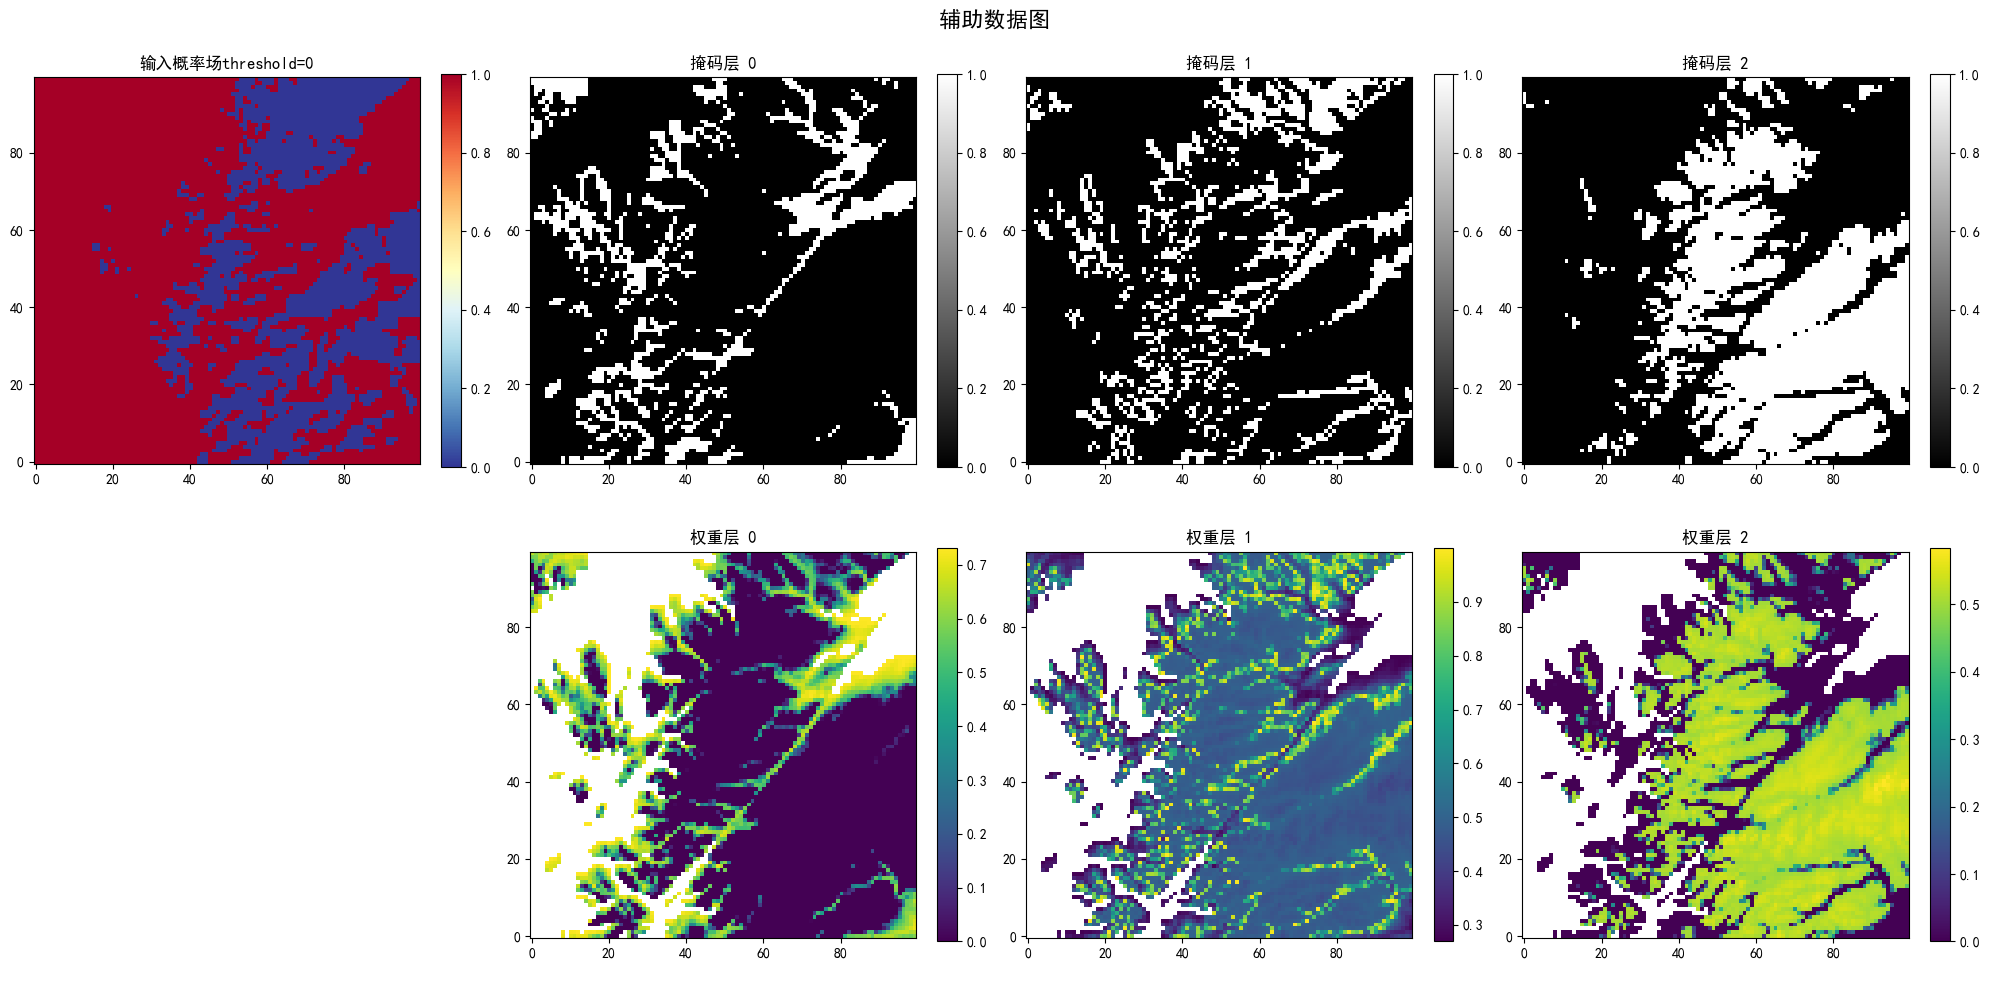

In [5]:
input_data = load_primary(RESOURCE_DIR / 'iterate_with_mask' / 'cli_input' / "thresholded_input.nc")
mask_data = load_primary(RESOURCE_DIR / 'iterate_with_mask' / 'cli_input' / "orographic_bands_mask.nc")
weights_data_raw = load_primary(RESOURCE_DIR / 'iterate_with_mask' / 'cli_input' / "orographic_bands_weights.nc")

plot_auxiliary_data(input_data, mask_data, weights_data_raw, threshold_index=THRESHOLD_INDEX)

In [6]:
# 在调用前打印形状
print("Input data shape:", input_data.shape)           # 预期: (n_threshold, y, x)
print("Mask data shape:", mask_data.shape)             # 预期: (n_mask, y, x)
print("Weights data shape:", weights_data_raw.shape)       # 预期: (n_mask, y, x)

# 选择单个阈值
data_2d = (
    input_data
    .isel(member=THRESHOLD_INDEX, level=0, time=0, dtime=0)
    .squeeze(drop=True)
)
print("Data slice shape:", data_2d.shape)           # 预期: (y, x)

Input data shape: (4, 1, 1, 1, 100, 100)
Mask data shape: (3, 100, 100)
Weights data shape: (3, 100, 100)
Data slice shape: (100, 100)


### 3.1 方形邻域折叠结果对比

调用迁移后的 `ApplyNeighbourhoodProcessingWithAMask` 生成方形邻域结果，并与官方 KGO、原算法结果做统一色标对比。

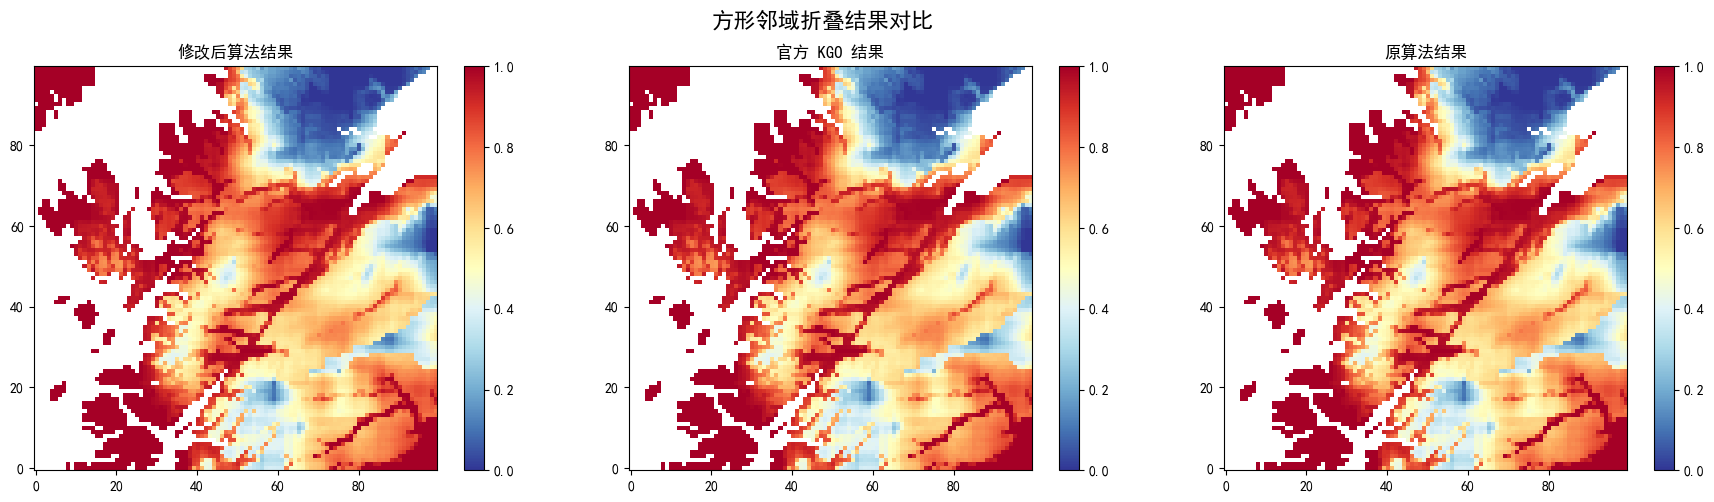

In [7]:
modified_square = ApplyNeighbourhoodProcessingWithAMask(
    COORD_FOR_MASKING,
    "square",
    RADIUS_METRES,
    collapse_weights=weights_data_raw,
).process(input_data, mask_data)

kgo_square = clean_fill_values(load_primary(RESOURCE_DIR / 'iterate_with_mask' / "basic_collapse_bands" / "kgo_collapsed.nc"))
original_square = clean_fill_values(load_primary(RESOURCE_DIR / 'iterate_with_mask' / "basic_collapse_bands" / "original_collapsed.nc"))

plot_result_comparison(
    "方形邻域折叠结果对比",
    modified_square.isel(member=THRESHOLD_INDEX, level=0, time=0, dtime=0).values,
    kgo_square.isel(threshold=THRESHOLD_INDEX).values,
    original_square.isel(threshold=THRESHOLD_INDEX).values,
)


### 3.2 圆形邻域折叠结果对比

调用迁移后的 `ApplyNeighbourhoodProcessingWithAMask` 生成圆形邻域结果，并与官方 KGO、原算法结果做统一色标对比。

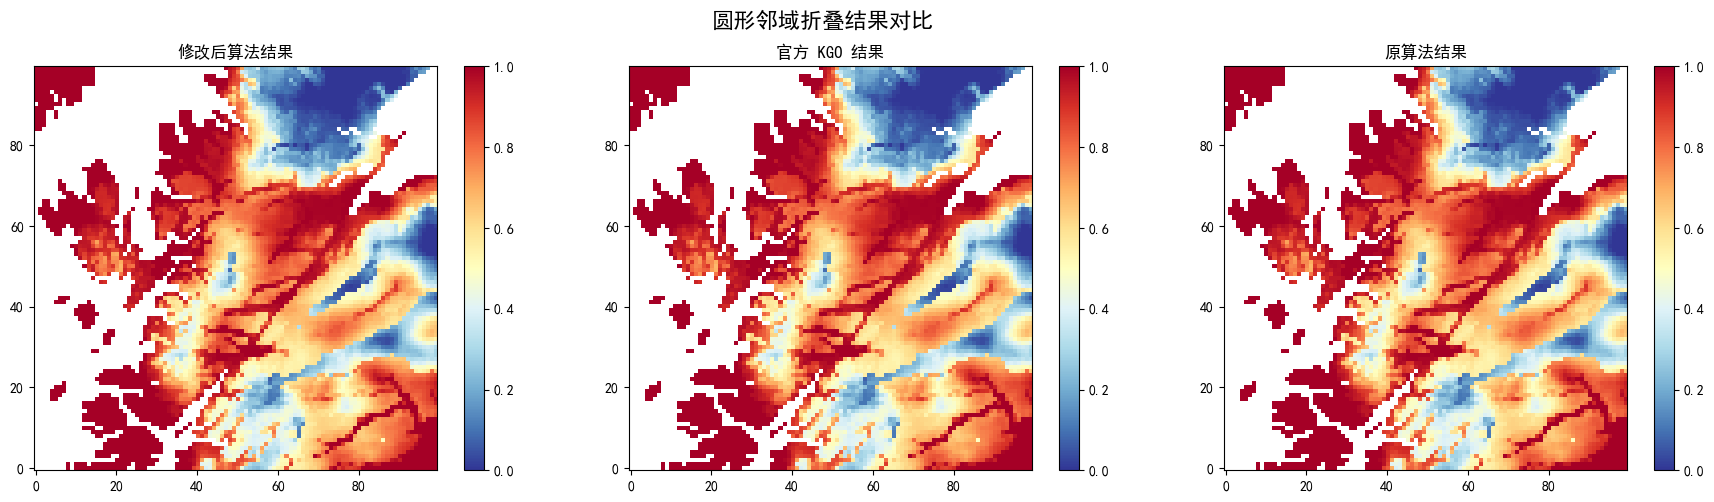

In [8]:
modified_circular = ApplyNeighbourhoodProcessingWithAMask(
    COORD_FOR_MASKING,
    "circular",
    RADIUS_METRES,
    collapse_weights=weights_data_raw,
).process(input_data, mask_data)

kgo_circular = clean_fill_values(load_primary(RESOURCE_DIR / 'iterate_with_mask' / "basic_collapse_bands" / "kgo_collapsed_circular.nc"))
original_circular = clean_fill_values(load_primary(RESOURCE_DIR / 'iterate_with_mask' / "basic_collapse_bands" / "original_collapsed_circular.nc"))

plot_result_comparison(
    "圆形邻域折叠结果对比",
    modified_circular.isel(member=THRESHOLD_INDEX, level=0, time=0, dtime=0).values,
    kgo_circular.isel(threshold=THRESHOLD_INDEX).values,
    original_circular.isel(threshold=THRESHOLD_INDEX).values,
)


## 4. 邻域结果不折叠
本节输入不包含地形带权重，结果不会进行折叠。

原算法结果中会新增一个掩码分层维度，修改后算法为限制输出维度将新增维度与原输入member维度进行融合。

In [9]:
#数据读取
input_path = RESOURCE_DIR / 'iterate_with_mask' / 'cli_input' / 'input.nc'
mask_path = RESOURCE_DIR / 'iterate_with_mask' / 'cli_input' / 'mask.nc'
kgo_path = RESOURCE_DIR / 'iterate_with_mask' / "basic" / 'kgo_basic.nc'
original_square_path = RESOURCE_DIR / 'iterate_with_mask' / "basic" / 'original_unfolded_result.nc'
original_circular_path = RESOURCE_DIR / 'iterate_with_mask' / "basic" / 'original_unfolded_circular_result.nc'

input_data = load_primary(input_path)
mask_data = load_primary(mask_path)
kgo_data = clean_fill_values(load_primary(kgo_path))
original_unfolded_square = clean_fill_values(load_primary(original_square_path))
original_unfolded_circular = clean_fill_values(load_primary(original_circular_path))

#算法调用
modified_unfolded_square = ApplyNeighbourhoodProcessingWithAMask(
    COORD_FOR_MASKING,
    "square",
    20000.0,
).process(input_data, mask_data)

modified_unfolded_circular = ApplyNeighbourhoodProcessingWithAMask(
    COORD_FOR_MASKING,
    "circular",
    20000.0,
).process(input_data, mask_data)

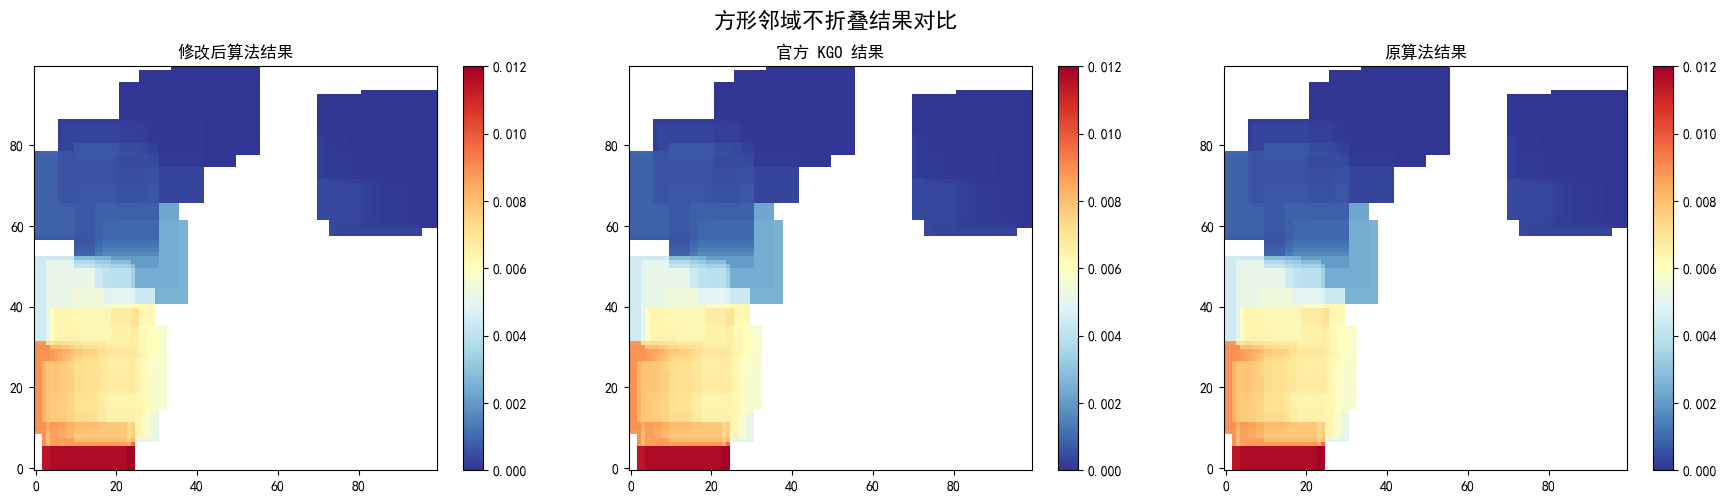

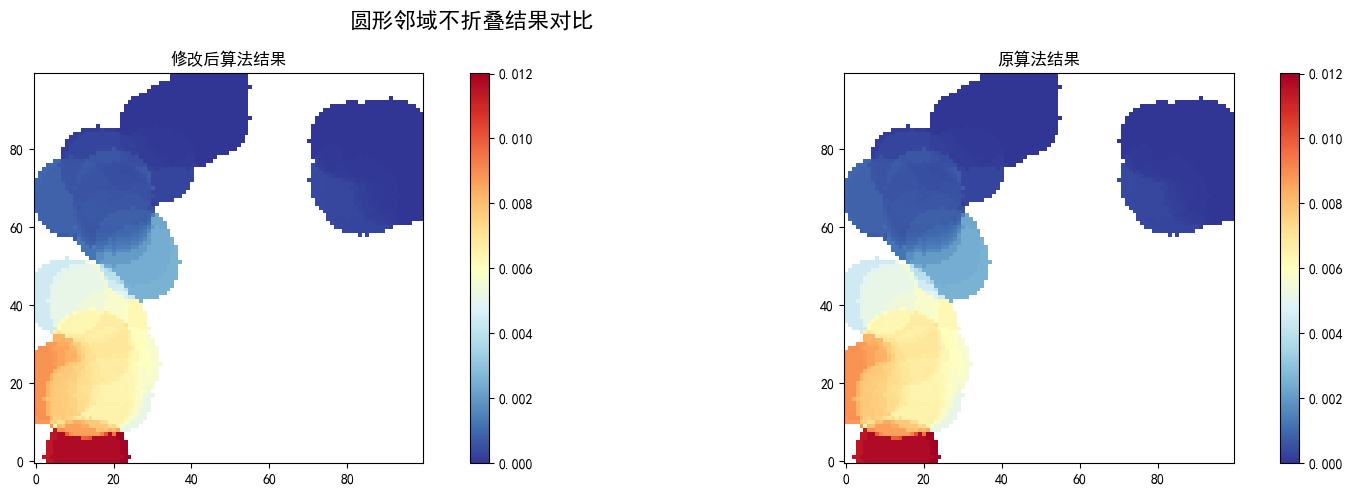

In [10]:
def to_plot_2d_unfolded(da, member_idx=0, zone_idx=0):
    out = da
    for dim in ("member", "threshold", "realization", "level", "time", "dtime"):
        if dim in out.dims:
            out = out.isel({dim: member_idx})
    if "topographic_zone" in out.dims:
        out = out.isel({"topographic_zone": zone_idx})
    out = out.squeeze(drop=True)
    return np.asarray(out.values)

plot_result_comparison(
    "方形邻域不折叠结果对比",
    to_plot_2d_unfolded(modified_unfolded_square, 0, 0),
    to_plot_2d_unfolded(kgo_data, 0, 0),
    to_plot_2d_unfolded(original_unfolded_square, 0, 0),
)

#圆形邻域结果
modified = to_plot_2d_unfolded(modified_unfolded_circular, 0, 0)
original = to_plot_2d_unfolded(original_unfolded_circular, 0, 0)
vmin, vmax = common_limits(modified, original)
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
panels = [
    (modified, "修改后算法结果"),
    (original, "原算法结果"),
]
for ax, (data, name) in zip(axes, panels):
    im = ax.imshow(data, origin="lower", cmap="RdYlBu_r", vmin=vmin, vmax=vmax, interpolation="nearest")
    ax.set_title(name)
    plt.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("圆形邻域不折叠结果对比", fontsize=16)
fig.tight_layout()
plt.show()


In [11]:
# 原算法结果——方形邻域不折叠
original_unfolded_square

<xarray.DataArray (realization: 3, topographic_zone: 3,
                   projection_y_coordinate: 100, projection_x_coordinate: 100)> Size: 720kB
array([[[[           nan,            nan, 1.14261238e-02, ...,
                     nan,            nan,            nan],
         [           nan,            nan, 1.14261238e-02, ...,
                     nan,            nan,            nan],
         [           nan,            nan, 1.14261238e-02, ...,
                     nan,            nan,            nan],
         ...,
         [           nan,            nan,            nan, ...,
                     nan,            nan,            nan],
         [           nan,            nan,            nan, ...,
                     nan,            nan,            nan],
         [           nan,            nan,            nan, ...,
                     nan,            nan,            nan]],

        [[1.25218602e-02, 1.24587072e-02, 1.16079869e-02, ...,
          2.84627685e-03, 2.84627685e-03, 2.84627685e-03],
         [1.25218602e-02, 1.24587072e-02, 1.16079869e-02, ...,
          2.84627685e-03, 2.84627685e-03, 2.84627685e-03],
         [1.25218602e-02, 1.24587072e-02, 1.16079869e-02, ...,
          2.84627685e-03, 2.84627685e-03, 2.84627685e-03],
...
          4.29700376e-05, 4.29700376e-05, 3.90636706e-05],
         [8.03595540e-05, 1.75420297e-04, 3.02743458e-04, ...,
          4.29700376e-05, 4.29700376e-05, 3.90636706e-05],
         [6.98638760e-05, 1.72661428e-04, 3.08114715e-04, ...,
          4.29700376e-05, 4.29700376e-05, 3.90636706e-05]],

        [[           nan,            nan,            nan, ...,
          2.90369475e-03, 2.88905436e-03, 2.88905436e-03],
         [           nan,            nan,            nan, ...,
          2.84584425e-03, 2.82993331e-03, 2.82993331e-03],
         [           nan,            nan,            nan, ...,
          2.77341227e-03, 2.75588618e-03, 2.75588618e-03],
         ...,
         [2.23131690e-04, 3.01208813e-04, 3.29773000e-04, ...,
          6.64082399e-05, 7.81273411e-05, 7.81273411e-05],
         [2.23131690e-04, 3.01208813e-04, 3.29773000e-04, ...,
          6.64082399e-05, 7.81273411e-05, 7.81273411e-05],
         [2.30312900e-04, 3.10483854e-04, 3.39072663e-04, ...,
          6.64082399e-05, 7.81273411e-05, 7.81273411e-05]]]],
      shape=(3, 3, 100, 100))
Coordinates:
  * realization              (realization) int32 12B 0 1 2
  * topographic_zone         (topographic_zone) float32 12B -250.0 25.0 75.0
  * projection_y_coordinate  (projection_y_coordinate) float32 400B 1.64e+05 ...
  * projection_x_coordinate  (projection_x_coordinate) float32 400B -2.58e+05...
    forecast_period          int32 4B 3600
    forecast_reference_time  datetime64[ns] 8B 2017-02-23T03:00:00
    time                     datetime64[ns] 8B 2017-02-23T04:00:00
Attributes:
    standard_name:  thickness_of_rainfall_amount
    units:          m
    cell_methods:   time: sum
    grid_mapping:   lambert_azimuthal_equal_area

In [12]:
# 修改后算法结果——方形邻域不折叠
modified_unfolded_square

<xarray.DataArray 'thickness_of_rainfall_amount' (member: 9, level: 1, time: 1,
                                                  dtime: 1, lat: 100, lon: 100)> Size: 360kB
array([[[[[[           nan,            nan, 1.14261238e-02, ...,
                       nan,            nan,            nan],
           [           nan,            nan, 1.14261238e-02, ...,
                       nan,            nan,            nan],
           [           nan,            nan, 1.14261238e-02, ...,
                       nan,            nan,            nan],
           ...,
           [           nan,            nan,            nan, ...,
                       nan,            nan,            nan],
           [           nan,            nan,            nan, ...,
                       nan,            nan,            nan],
           [           nan,            nan,            nan, ...,
                       nan,            nan,            nan]]]]],




       [[[[[1.25218602e-02, 1.24587072e-02, 1.16079869e-02, ...,
            2.84627685e-03, 2.84627685e-03, 2.84627685e-03],
           [1.25218602e-02, 1.24587072e-02, 1.16079869e-02, ...,
...
           [6.98638760e-05, 1.72661428e-04, 3.08114715e-04, ...,
            4.29700376e-05, 4.29700376e-05, 3.90636706e-05]]]]],




       [[[[[           nan,            nan,            nan, ...,
            2.90369475e-03, 2.88905436e-03, 2.88905436e-03],
           [           nan,            nan,            nan, ...,
            2.84584425e-03, 2.82993331e-03, 2.82993331e-03],
           [           nan,            nan,            nan, ...,
            2.77341227e-03, 2.75588618e-03, 2.75588618e-03],
           ...,
           [2.23131690e-04, 3.01208813e-04, 3.29773000e-04, ...,
            6.64082399e-05, 7.81273411e-05, 7.81273411e-05],
           [2.23131690e-04, 3.01208813e-04, 3.29773000e-04, ...,
            6.64082399e-05, 7.81273411e-05, 7.81273411e-05],
           [2.30312900e-04, 3.10483854e-04, 3.39072663e-04, ...,
            6.64082399e-05, 7.81273411e-05, 7.81273411e-05]]]]]],
      shape=(9, 1, 1, 1, 100, 100), dtype=float32)
Coordinates:
  * member               (member) int32 36B 0 1 2 3 4 5 6 7 8
    member_input_member  (member) int32 36B 0 0 0 1 1 1 2 2 2
    member_mask_layer    (member) float32 36B -250.0 25.0 75.0 ... 25.0 75.0
  * level                (level) float32 4B 0.0
  * time                 (time) datetime64[ns] 8B 1970-01-01
  * dtime                (dtime) int32 4B 0
  * lat                  (lat) float32 400B 1.64e+05 1.66e+05 ... 3.62e+05
  * lon                  (lon) float32 400B -2.58e+05 -2.56e+05 ... -6e+04
Attributes:
    units:              m
    model:              
    dtime_units:        hour
    level_type:         isobaric
    time_type:          UT
    time_bounds:        [0 0]
    member_is_stacked:  True
    member_stack_dims:  member,topographic_zone

## CLI 应用
ApplyNeighbourhoodProcessingWithAMask 相关示例脚本：
1. `neighbourhood_probability_processing/cli/ens_nbhood_iterate_with_mask.py`
2. `neighbourhood_probability_processing/cli/ens_nbhood_land_and_sea.py`

In [13]:
#CLI应用部分通用辅助函数
def _first_2d(da):
    """提取第一个2D切片"""
    out = da
    for dim in ('member', 'threshold', 'realization', 'topographic_zone'):
        if dim in out.dims:
            out = out.isel({dim: 0})
    out = out.squeeze(drop=True)
    return np.asarray(out)

def load_data(path, var_name='air_temperature'):
    """智能加载变量：优先使用指定变量名，未指定时自动选择主变量。

    读入内存后立即关闭数据集句柄，避免 Windows 下文件被内核长期占用而无法覆盖。
    """
    try:
        ds = xr.open_dataset(path, engine='netcdf4')
    except Exception:
        return None
    try:
        if var_name in ds.variables:
            return ds[var_name].load()
        # 自动选择主变量：跳过边界变量和网格映射变量
        for name, da in ds.data_vars.items():
            if name.endswith('_bnds'):
                continue
            if da.ndim == 0 and 'grid_mapping_name' in da.attrs:
                continue
            return da.load()
        return None
    finally:
        ds.close()

def plot_result_comparison(title, cli_modified, cli_original, kgo_reference):
    """绘制修改后算法、KGO 和原算法结果对比图。"""
    cli_orig_2d = _first_2d(cli_original)
    cli_mod_2d = _first_2d(cli_modified)
    kgo_2d = _first_2d(kgo_reference)
    vmin, vmax = common_limits(cli_orig_2d, cli_mod_2d, kgo_2d)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    panels = [
        (cli_mod_2d, "修改后CLI结果"),
        (cli_orig_2d, "原CLI结果"),
        (kgo_2d, "预期结果"),
    ]
    for ax, (data, name) in zip(axes, panels):
        im = ax.imshow(data, origin="lower", cmap="RdYlBu_r", vmin=vmin, vmax=vmax, interpolation="nearest")
        ax.set_title(name)
        plt.colorbar(im, ax=ax, fraction=0.046)
    fig.suptitle(title, fontsize=16)
    fig.tight_layout()
    plt.show()

### 1. ens_nbhood_iterate_with_mask.py

无权重（方形邻域）示例（脚本默认示例为方形折叠，需调相关参数后运行）：
```powershell
python -m neighbourhood_probability_processing.cli.ens_nbhood_iterate_with_mask
```

在 Notebook 中调用 `process()`（输入取自 `cli_input`，结果写入 `cli_output`）

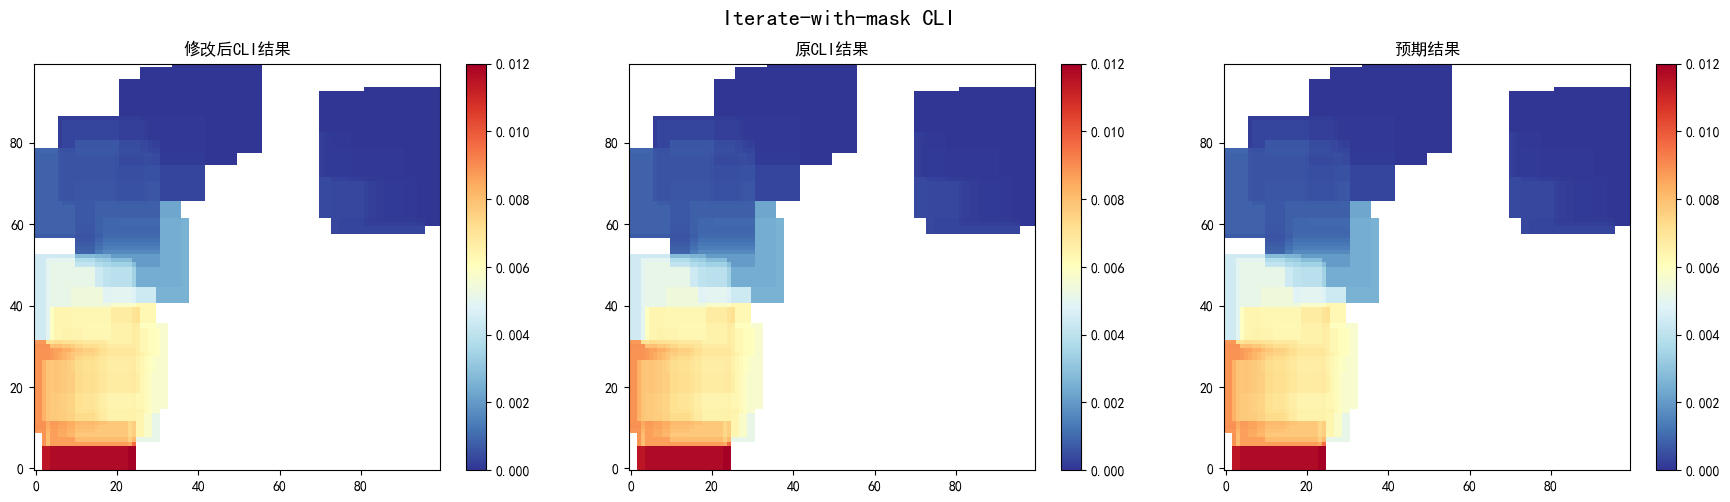

In [14]:
from neighbourhood_probability_processing.cli.ens_nbhood_iterate_with_mask import process as iterate_process

iterate_cli_input = RESOURCE_DIR / 'iterate_with_mask' / 'cli_input'
iterate_cli_output = RESOURCE_DIR / 'iterate_with_mask' / 'cli_output'

# 直接调用 CLI process() 处理输入，并把结果写出到 cli_output（无权重、方形、不折叠）
cli_iter_square = iterate_process(
    str(iterate_cli_input / 'input.nc'),
    str(iterate_cli_input / 'mask.nc'),
    'topographic_zone',
    [20000.0],
    output_path=str(iterate_cli_output / 'cli_unfolded_square_result.nc'),
    neighbourhood_shape='square',
)

original_cli_path = RESOURCE_DIR / 'iterate_with_mask' / 'basic' / 'cli_unfolded_square_result.nc'
original_cli_square = clean_fill_values(load_primary(original_cli_path))

plot_result_comparison("Iterate-with-mask CLI", cli_iter_square, original_cli_square, kgo_data)

带权重折叠示例（脚本默认示例为方形折叠，可直接运行）：

```powershell
python -m neighbourhood_probability_processing.cli.ens_nbhood_iterate_with_mask
```


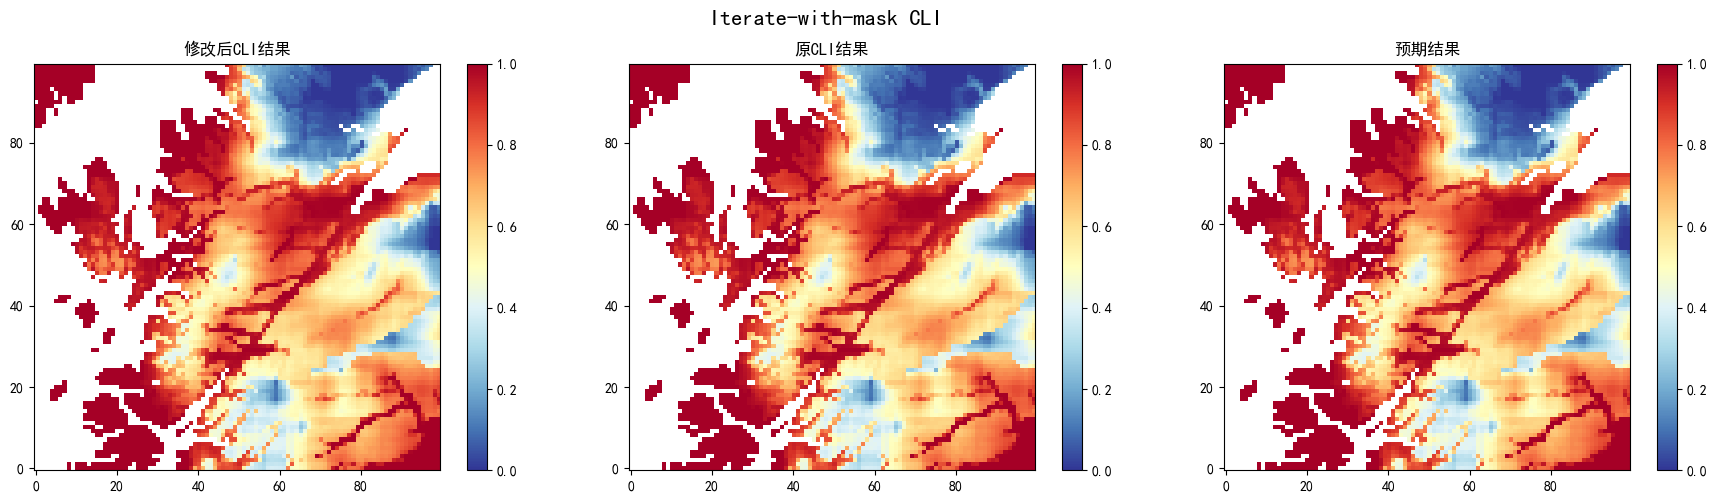

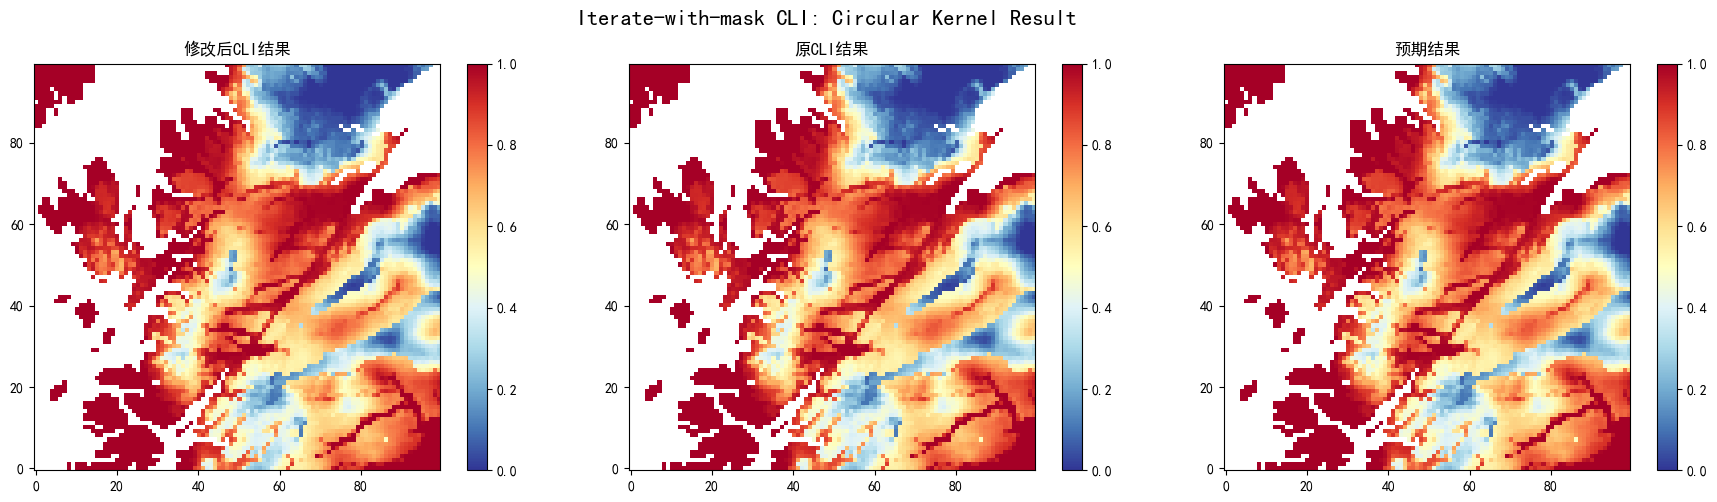

In [15]:
from neighbourhood_probability_processing.cli.ens_nbhood_iterate_with_mask import process as iterate_process

iterate_cli_input = RESOURCE_DIR / 'iterate_with_mask' / 'cli_input'
iterate_cli_output = RESOURCE_DIR / 'iterate_with_mask' / 'cli_output'

# 带权重折叠：方形 / 圆形，半径 10000 与官方 KGO 对齐
cli_iter_square = iterate_process(
    str(iterate_cli_input / 'thresholded_input.nc'),
    str(iterate_cli_input / 'orographic_bands_mask.nc'),
    'topographic_zone',
    radii=[10000.0],
    weights_path=str(iterate_cli_input / 'orographic_bands_weights.nc'),
    output_path=str(iterate_cli_output / 'cli_iterated_result.nc'),
    neighbourhood_shape='square',
)
cli_iter_circular = iterate_process(
    str(iterate_cli_input / 'thresholded_input.nc'),
    str(iterate_cli_input / 'orographic_bands_mask.nc'),
    'topographic_zone',
    radii=[10000.0],
    weights_path=str(iterate_cli_input / 'orographic_bands_weights.nc'),
    output_path=str(iterate_cli_output / 'cli_iterated_circular_result.nc'),
    neighbourhood_shape='circular',
)

original_cli_path = RESOURCE_DIR / 'iterate_with_mask' / 'basic_collapse_bands' / 'cli_iterated_result.nc'
original_cli_path_circular = RESOURCE_DIR / 'iterate_with_mask' / 'basic_collapse_bands' / 'cli_iterated_circular_result.nc'
original_cli_square = clean_fill_values(load_primary(original_cli_path))
original_cli_circular = clean_fill_values(load_primary(original_cli_path_circular))

plot_result_comparison("Iterate-with-mask CLI", cli_iter_square, original_cli_square, kgo_square)

plot_result_comparison("Iterate-with-mask CLI: Circular Kernel Result", cli_iter_circular, original_cli_circular, kgo_circular)

### 2. ens_nbhood_land_and_sea.py

In [16]:
def _plot_comparison_simple(title, cli_original, cli_modified, kgo_reference):
    """简化对比：只显示原始数据，不显示差异图"""
    cli_orig_2d = _first_2d(cli_original)
    cli_mod_2d = _first_2d(cli_modified)
    kgo_2d = _first_2d(kgo_reference)
    
    # 计算共同范围
    vmin = min(np.nanmin(cli_orig_2d), np.nanmin(cli_mod_2d), np.nanmin(kgo_2d))
    vmax = max(np.nanmax(cli_orig_2d), np.nanmax(cli_mod_2d), np.nanmax(kgo_2d))
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 左侧：修改后CLI结果
    im0 = axes[0].imshow(cli_mod_2d, origin='lower', cmap='viridis', vmin=vmin, vmax=vmax, interpolation='nearest')
    axes[0].set_title('修改后CLI结果')
    plt.colorbar(im0, ax=axes[0], fraction=0.046, label='温度 (K)')
    
    # 中间：原始CLI结果
    im1 = axes[1].imshow(cli_orig_2d, origin='lower', cmap='viridis', vmin=vmin, vmax=vmax, interpolation='nearest')
    axes[1].set_title('原始CLI结果')
    plt.colorbar(im1, ax=axes[1], fraction=0.046, label='温度 (K)')
    
    # 右侧：KGO参考结果
    im2 = axes[2].imshow(kgo_2d, origin='lower', cmap='viridis', vmin=vmin, vmax=vmax, interpolation='nearest')
    axes[2].set_title('KGO参考结果')
    plt.colorbar(im2, ax=axes[2], fraction=0.046, label='温度 (K)')
    
    fig.suptitle(title, fontsize=16)
    fig.tight_layout()
    plt.show()
    
    # 打印统计信息
    diff_orig_mod = cli_orig_2d - cli_mod_2d
    diff_orig_kgo = cli_orig_2d - kgo_2d
    diff_mod_kgo = cli_mod_2d - kgo_2d
    
    print(f"\n=== {title} 统计信息 ===")
    print(f"原始CLI vs 修改CLI: RMSE={np.sqrt(np.nanmean(diff_orig_mod**2)):.6f}, Bias={np.nanmean(diff_orig_mod):.6f}")
    print(f"原始CLI vs KGO: RMSE={np.sqrt(np.nanmean(diff_orig_kgo**2)):.6f}, Bias={np.nanmean(diff_orig_kgo):.6f}")
    print(f"修改CLI vs KGO: RMSE={np.sqrt(np.nanmean(diff_mod_kgo**2)):.6f}, Bias={np.nanmean(diff_mod_kgo):.6f}")

#### 2.1 简单陆地-海洋掩膜输入示例

方形邻域（脚本内置默认示例）：

```powershell
python -m neighbourhood_probability_processing.cli.ens_nbhood_land_and_sea
```

In [17]:
from neighbourhood_probability_processing.cli.ens_nbhood_land_and_sea import process as land_sea_process

# 路径定义
land_dir = RESOURCE_DIR / 'land_and_sea' / "no_topographic_bands"
land_cli_input = RESOURCE_DIR / 'land_and_sea' / 'cli_input'
land_cli_output = RESOURCE_DIR / 'land_and_sea' / 'cli_output'

# 调用 CLI process() 处理输入并写出到 cli_output（陆海简单掩码，半径 20000）
cli_mod_sq = land_sea_process(
    str(land_cli_input / 'input.nc'),
    str(land_cli_input / 'ukvx_landmask.nc'),
    radii=[20000.0],
    output_path=str(land_cli_output / 'cli_land_sea_result.nc'),
    neighbourhood_shape='square',
)
cli_mod_ci = land_sea_process(
    str(land_cli_input / 'input.nc'),
    str(land_cli_input / 'ukvx_landmask.nc'),
    radii=[20000.0],
    output_path=str(land_cli_output / 'cli_circular_result.nc'),
    neighbourhood_shape='circular',
)

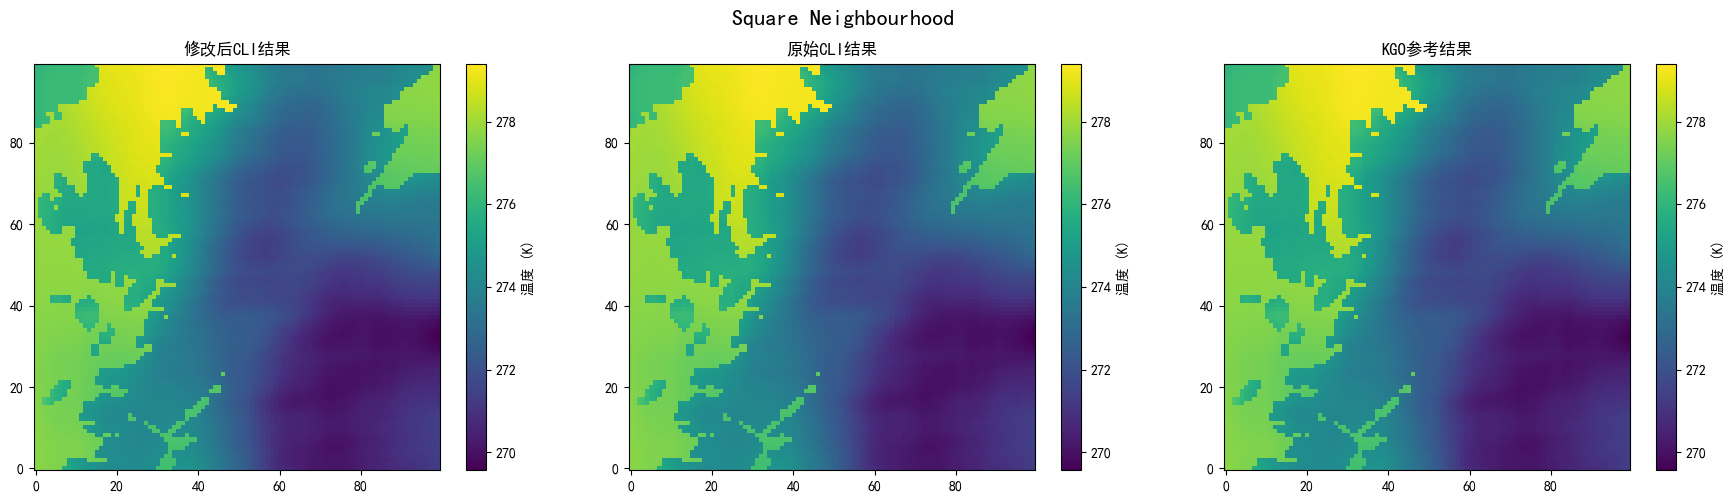


=== Square Neighbourhood 统计信息 ===
原始CLI vs 修改CLI: RMSE=0.000000, Bias=0.000000
原始CLI vs KGO: RMSE=0.000000, Bias=0.000000
修改CLI vs KGO: RMSE=0.000000, Bias=0.000000


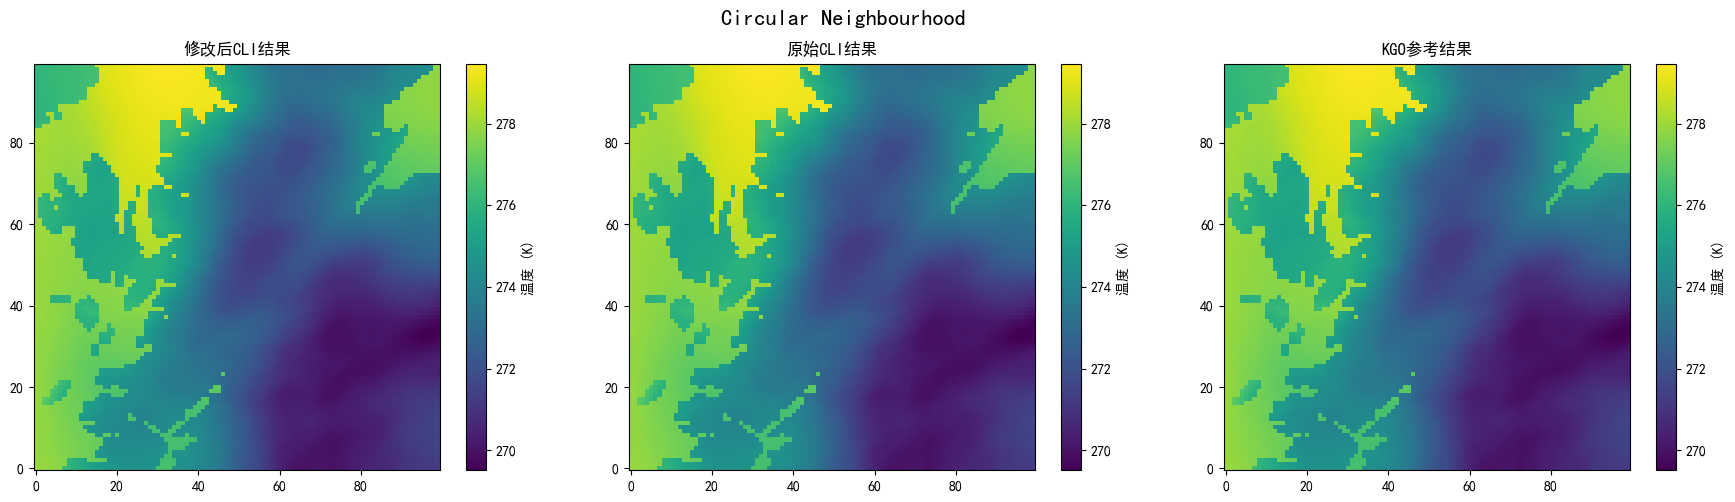


=== Circular Neighbourhood 统计信息 ===
原始CLI vs 修改CLI: RMSE=0.000000, Bias=0.000000
原始CLI vs KGO: RMSE=0.000000, Bias=0.000000
修改CLI vs KGO: RMSE=0.000000, Bias=0.000000


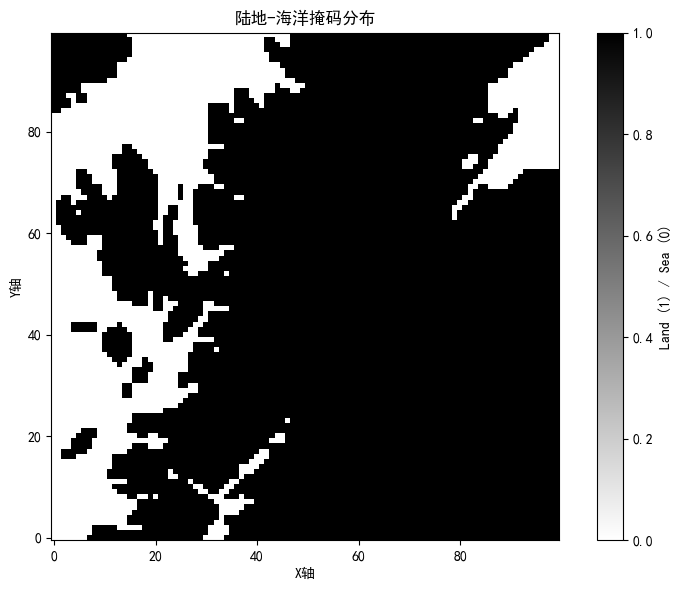

In [18]:
# 原始 CLI 参考结果与 KGO（保存的官方样例，直接读取）
cli_orig_sq = load_data(land_dir / 'cli_land_sea_result.nc')
kgo_sq = load_data(land_dir / 'kgo.nc')
cli_orig_ci = load_data(land_dir / 'cli_circular_result.nc')
kgo_ci = load_data(land_dir / 'kgo_circular.nc')

if cli_orig_sq is not None and cli_mod_sq is not None and kgo_sq is not None:
    _plot_comparison_simple("Square Neighbourhood", cli_orig_sq, cli_mod_sq, kgo_sq)

if cli_orig_ci is not None and cli_mod_ci is not None and kgo_ci is not None:
    _plot_comparison_simple("Circular Neighbourhood", cli_orig_ci, cli_mod_ci, kgo_ci)

# 加载并显示陆地-海洋掩码
try:
    landmask = load_primary(land_cli_input / 'ukvx_landmask.nc')
    landmask_2d = _first_2d(landmask)

    plt.figure(figsize=(8, 6))
    plt.imshow(landmask_2d, cmap='binary', origin='lower')
    plt.colorbar(label='Land (1) / Sea (0)')
    plt.title('陆地-海洋掩码分布')
    plt.xlabel('X轴')
    plt.ylabel('Y轴')
    plt.tight_layout()
    plt.show()
except Exception as e:
    pass

#### 2.2 地形带掩膜输入示例

In [19]:
from neighbourhood_probability_processing.cli.ens_nbhood_land_and_sea import process as land_sea_process

# 原始CLI结果路径
topo_bands_dir = RESOURCE_DIR / 'land_and_sea' / 'topographic_bands'
# 预处理输入 / 修改算法CLI结果路径
land_cli_input = RESOURCE_DIR / 'land_and_sea' / 'cli_input'
land_cli_output = RESOURCE_DIR / 'land_and_sea' / 'cli_output'

# 地形带：带权重折叠，方形 / 圆形，半径 20000
cli_mod_sq = land_sea_process(
    str(land_cli_input / 'input.nc'),
    str(land_cli_input / 'topographic_bands_land.nc'),
    radii=[20000.0],
    weights_path=str(land_cli_input / 'weights_land.nc'),
    output_path=str(land_cli_output / 'cli_topographic_bands_result.nc'),
    neighbourhood_shape='square',
)
cli_mod_ci = land_sea_process(
    str(land_cli_input / 'input.nc'),
    str(land_cli_input / 'topographic_bands_land.nc'),
    radii=[20000.0],
    weights_path=str(land_cli_input / 'weights_land.nc'),
    output_path=str(land_cli_output / 'cli_topographic_bands_circular_result.nc'),
    neighbourhood_shape='circular',
)

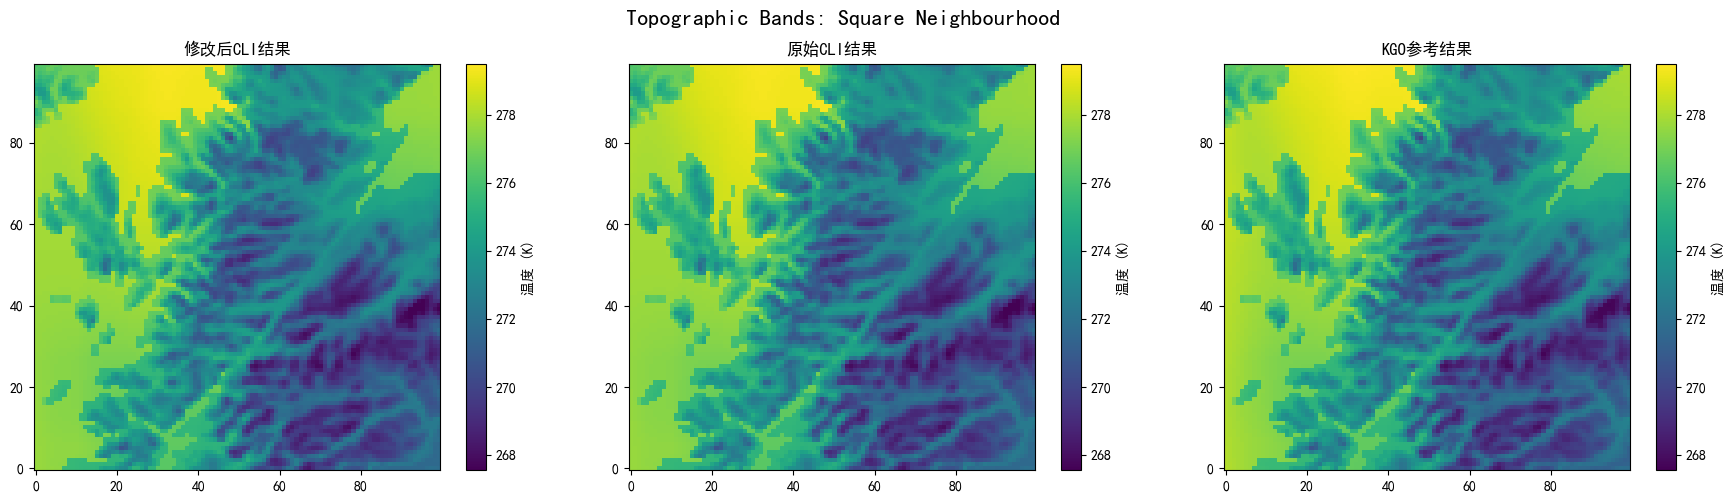


=== Topographic Bands: Square Neighbourhood 统计信息 ===
原始CLI vs 修改CLI: RMSE=0.000000, Bias=0.000000
原始CLI vs KGO: RMSE=0.110129, Bias=-0.022400
修改CLI vs KGO: RMSE=0.110129, Bias=-0.022400


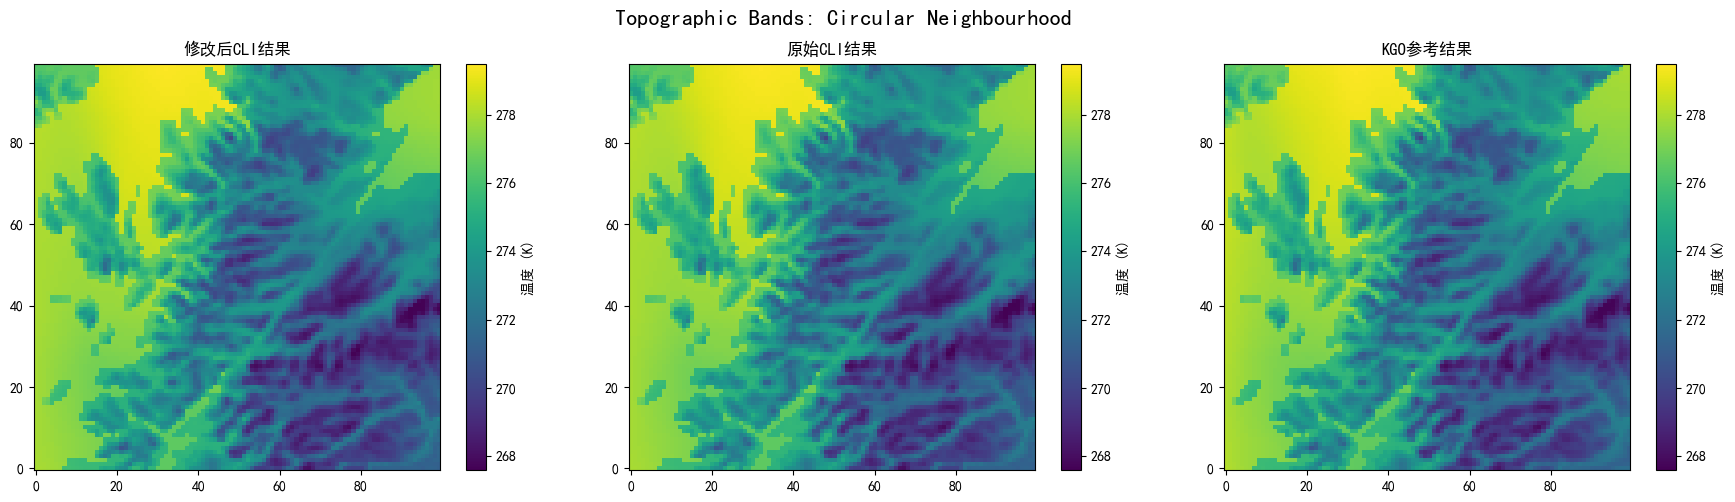


=== Topographic Bands: Circular Neighbourhood 统计信息 ===
原始CLI vs 修改CLI: RMSE=0.000000, Bias=0.000000
原始CLI vs KGO: RMSE=0.114615, Bias=-0.018586
修改CLI vs KGO: RMSE=0.114615, Bias=-0.018586


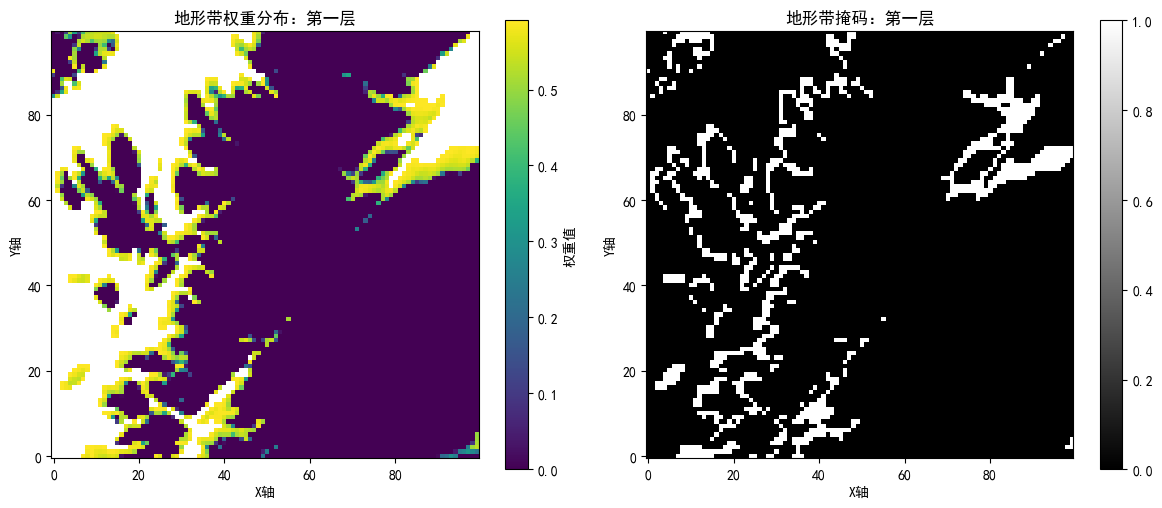

In [20]:
# 原始 CLI 参考结果与 KGO（保存的官方样例，直接读取）
cli_orig_sq = load_data(topo_bands_dir / 'cli_topographic_bands_square_result.nc')
kgo_sq = load_data(topo_bands_dir / 'kgo.nc')
cli_orig_ci = load_data(topo_bands_dir / 'cli_topographic_bands_circular_result.nc')
kgo_ci = load_data(topo_bands_dir / 'kgo_circular.nc')
if kgo_ci is None:
    kgo_ci = kgo_sq  # 如果没有专门的圆形KGO，使用方形的KGO

# 检查并执行对比
if cli_orig_sq is not None and cli_mod_sq is not None and kgo_sq is not None:
    _plot_comparison_simple("Topographic Bands: Square Neighbourhood", cli_orig_sq, cli_mod_sq, kgo_sq)

if cli_orig_ci is not None and cli_mod_ci is not None and kgo_ci is not None:
    _plot_comparison_simple("Topographic Bands: Circular Neighbourhood", cli_orig_ci, cli_mod_ci, kgo_ci)

# 加载并显示地形带权重和掩码
try:
    weights = load_primary(land_cli_input / 'weights_land.nc', 'topographic_zone_weights')
    weights_2d = _first_2d(weights)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(weights_2d, cmap='viridis', origin='lower')
    plt.colorbar(label='权重值')
    plt.title('地形带权重分布：第一层')
    plt.xlabel('X轴')
    plt.ylabel('Y轴')

    topo_mask = load_primary(land_cli_input / 'topographic_bands_land.nc', 'topography_mask')

    if topo_mask is not None:
        topo_mask_2d = _first_2d(topo_mask)

        plt.subplot(1, 2, 2)
        plt.imshow(topo_mask_2d, cmap='gray', origin='lower')
        plt.colorbar()
        plt.title('地形带掩码：第一层')
        plt.xlabel('X轴')
        plt.ylabel('Y轴')

        plt.tight_layout()
        plt.show()
except Exception as e:
    pass

## 5. 数据展示

本节只对插件结果做单图展示，便于快速查看 `use_nbhood` 在不同处理路径下生成的二维结果场，不再重复绘制 KGO、原算法或 CLI 对照图。

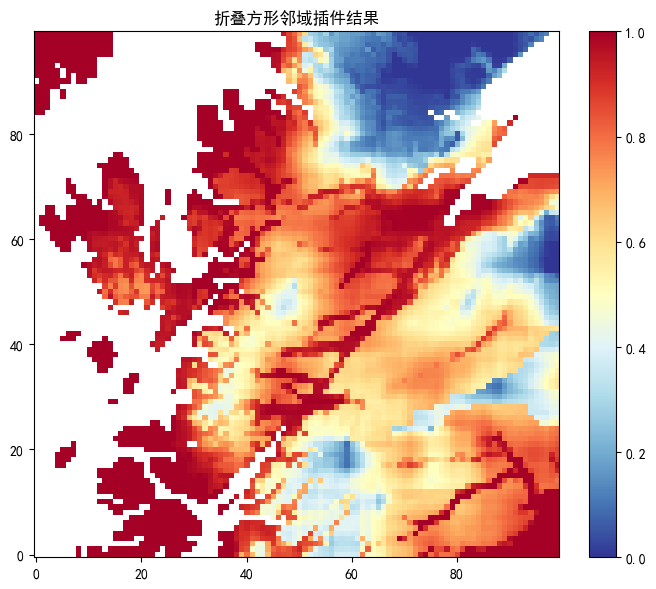

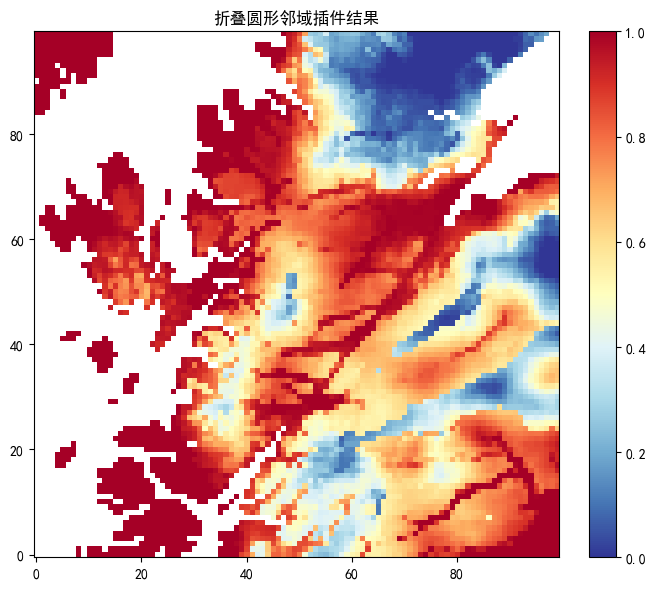

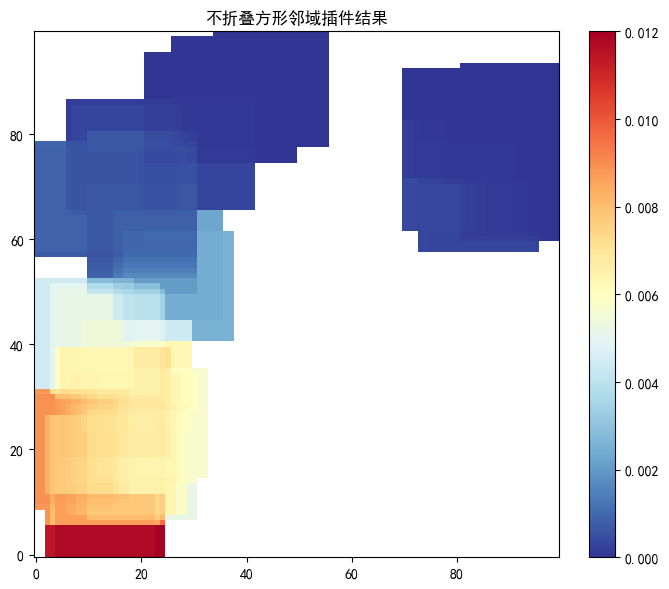

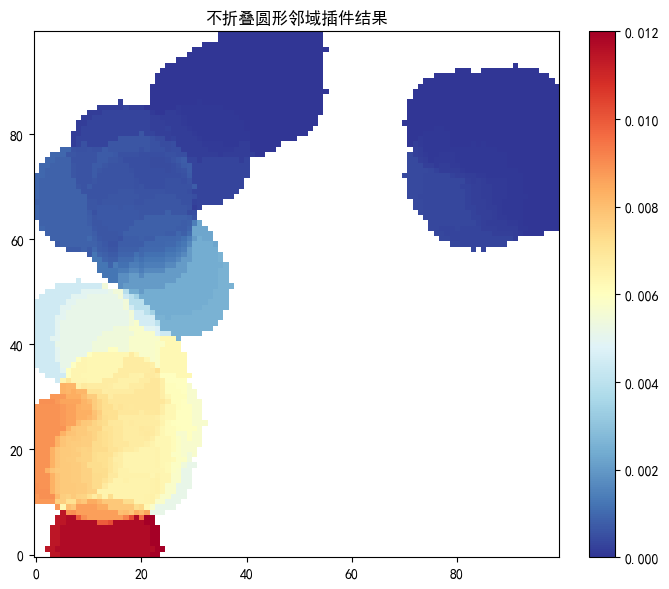

In [21]:
def plot_plugin_field(title, data, cmap="RdYlBu_r"):
    """单独绘制一个插件输出二维场。"""
    values = np.ma.asarray(data)
    plt.figure(figsize=(8, 6))
    plt.imshow(values, origin="lower", cmap=cmap, interpolation="nearest")
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.title(title)
    plt.tight_layout()
    plt.show()


collapse_norm_dir = RESOURCE_DIR / 'iterate_with_mask' / 'cli_input'

if "modified_square" not in globals() or "modified_circular" not in globals():
    collapse_input = load_primary(collapse_norm_dir / 'thresholded_input.nc')
    collapse_mask = load_primary(collapse_norm_dir / 'orographic_bands_mask.nc')
    collapse_weights = load_primary(collapse_norm_dir / 'orographic_bands_weights.nc')

    if "modified_square" not in globals():
        modified_square = ApplyNeighbourhoodProcessingWithAMask(
            COORD_FOR_MASKING,
            'square',
            RADIUS_METRES,
            collapse_weights=collapse_weights,
        ).process(collapse_input, collapse_mask)

    if "modified_circular" not in globals():
        modified_circular = ApplyNeighbourhoodProcessingWithAMask(
            COORD_FOR_MASKING,
            'circular',
            RADIUS_METRES,
            collapse_weights=collapse_weights,
        ).process(collapse_input, collapse_mask)

if "modified_unfolded_square" not in globals() or "modified_unfolded_circular" not in globals():
    unfolded_input = load_primary(collapse_norm_dir / 'input.nc')
    unfolded_mask = load_primary(collapse_norm_dir / 'mask.nc')

    if "modified_unfolded_square" not in globals():
        modified_unfolded_square = ApplyNeighbourhoodProcessingWithAMask(
            COORD_FOR_MASKING,
            'square',
            RADIUS_METRES,
        ).process(unfolded_input, unfolded_mask)

    if "modified_unfolded_circular" not in globals():
        modified_unfolded_circular = ApplyNeighbourhoodProcessingWithAMask(
            COORD_FOR_MASKING,
            'circular',
            RADIUS_METRES,
        ).process(unfolded_input, unfolded_mask)

plot_plugin_field(
    '折叠方形邻域插件结果',
    modified_square.isel(member=THRESHOLD_INDEX, level=0, time=0, dtime=0).values,
)
plot_plugin_field(
    '折叠圆形邻域插件结果',
    modified_circular.isel(member=THRESHOLD_INDEX, level=0, time=0, dtime=0).values,
)
plot_plugin_field(
    '不折叠方形邻域插件结果',
    to_plot_2d_unfolded(modified_unfolded_square, 0, 0),
)
plot_plugin_field(
    '不折叠圆形邻域插件结果',
    to_plot_2d_unfolded(modified_unfolded_circular, 0, 0),
)